# Classical Grading Method

This notebook continues the OMR pipeline after bubble detection. The goal is to turn detected bubbles into answers, then compare those answers with a teacher answer key.

For this first method we stay close to the classical path from the reference paper: detect the answer section, order the option circles, group them into rows of four choices, assign a response, and report cases that need human review.

## Method Idea

At this stage we already have bubble candidates and a simple dark-pixel score for each candidate. The grading layer adds structure:

1. split the answer section into vertical option blocks,
2. group bubbles by row inside each block,
3. assign `A`, `B`, `C`, or `D` when exactly one option is marked,
4. assign `X` when no option is marked,
5. assign `M` when multiple options are marked,
6. assign `?` when the mark is unclear and should be reviewed.

This is still a baseline. The important thing is that each decision is visible and explainable.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from bubble_detection import draw_mark_scores
from classical_grading import (
    load_answer_key,
    run_classical_omr_pipeline,
    save_grading_report,
)

In [2]:
def load_rgb(path):
    return np.array(Image.open(path).convert("RGB"))


def show_image(image, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    if image.ndim == 2:
        ax.imshow(image, cmap="gray")
    else:
        ax.imshow(image)

    ax.set_title(title)
    ax.axis("off")
    return ax


def print_answer_rows(rows, limit=20):
    print(f"{'Q':>3}  {'Ans':>3}  {'Key':>3}  {'Status':<9}  {'Review'}")
    print("-" * 42)

    for row in rows[:limit]:
        key = row.get("correct_answer") or "-"
        review = row.get("review_reason") or ""
        print(
            f"{row['question']:>3}  {row['answer']:>3}  "
            f"{key:>3}  {row['status']:<9}  {review}"
        )

## 1. Choose the Sheet and Answer Key

`answer_keys/demo_100_questions.json` is only a demo key so we can test the machinery. For a real exam, replace that file with the correct teacher answers before trusting the score.

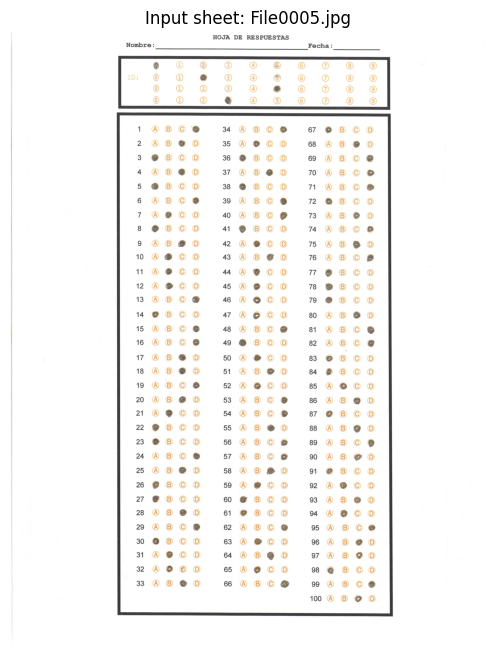

In [3]:
source_path = Path("samples/File0005.jpg")
answer_key_path = Path("answer_keys/demo_100_questions.json")
report_path = Path("outputs/classical_grading_File0005.json")

original_image = load_rgb(source_path)
answer_key = load_answer_key(answer_key_path)

show_image(original_image, f"Input sheet: {source_path.name}");

## 2. Run the Classical OMR Pipeline

This single call runs the previous stages and then adds the grading layer:

- resize and grayscale,
- detect the two largest rectangles,
- warp the answer rectangle,
- detect and score bubbles,
- group bubbles into answer rows,
- compare with the answer key.

In [4]:
result = run_classical_omr_pipeline(
    original_image,
    answer_key=answer_key,
    working_size=(900, 1200),
    mark_threshold=0.18,
    weak_threshold=0.08,
)

grading = result["grading"]
save_grading_report(
    report_path,
    interpreted_rows=grading["answers"],
    grading=grading,
    layout=result["layout"],
)

print("Layout:")
for key, value in result["layout"].items():
    print(f"  {key}: {value}")

print("\nSummary:")
for key, value in grading["summary"].items():
    print(f"  {key}: {value}")

print(f"\nSaved report to: {report_path}")

Layout:
  option_column_count: 12
  answer_section_count: 3
  questions_detected: 100
  warnings: []

Summary:
  questions_detected: 100
  questions_in_answer_key: 100
  correct: 20
  incorrect: 80
  blank: 0
  multiple: 0
  unclear: 0
  needs_review: 0
  score_percent: 20.0

Saved report to: outputs/classical_grading_File0005.json


## 3. Visual Checkpoint

The overlay below shows the warped answer section with bubble candidates. Green circles are candidates; red circles are candidates whose dark-pixel score passes the mark threshold.

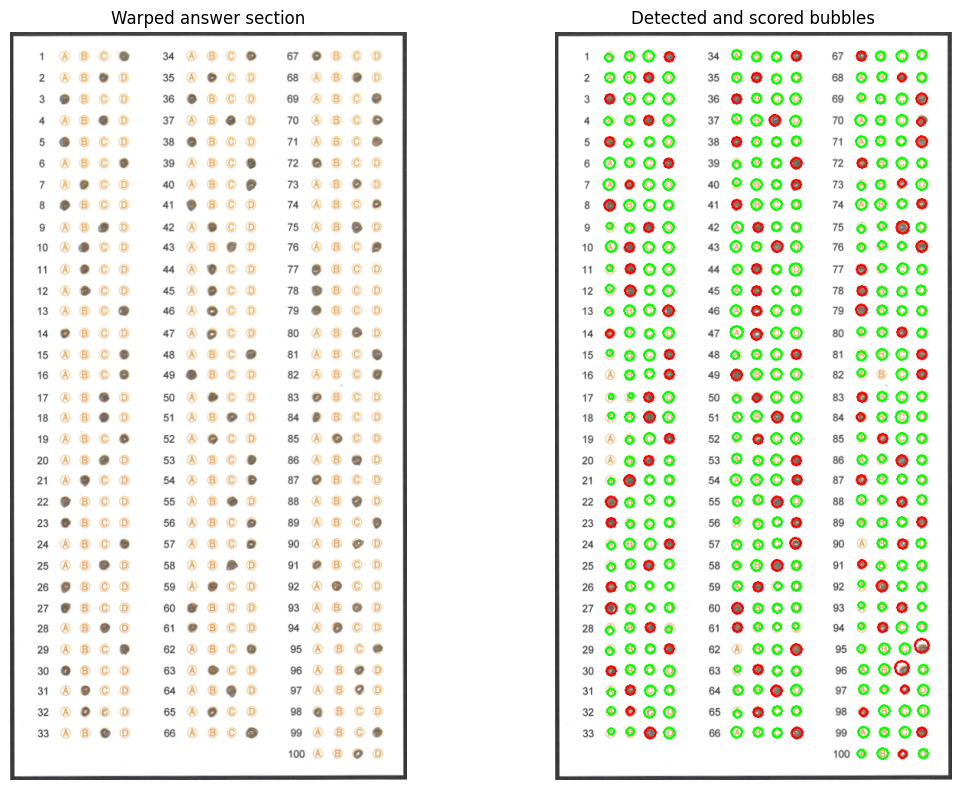

In [5]:
answer_section = result["answer_section"]["warped_image"]
bubble_overlay = draw_mark_scores(
    answer_section,
    result["scored_bubbles"],
    mark_threshold=0.18,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
show_image(answer_section, "Warped answer section", axes[0])
show_image(bubble_overlay, "Detected and scored bubbles", axes[1])
plt.tight_layout()

## 4. Interpreted Answers

The table prints the first rows so we can inspect how the system is translating image evidence into answer values. `M` means multiple marks, `X` means blank, and `?` means unclear.

In [6]:
graded_rows = grading["answers"]
print_answer_rows(graded_rows, limit=25)

status_counts = Counter(row["status"] for row in graded_rows)
print("\nStatus counts:")
for status, count in status_counts.items():
    print(f"  {status}: {count}")

  Q  Ans  Key  Status     Review
------------------------------------------
  1    D    A  single     
  2    C    B  single     
  3    A    C  single     
  4    C    D  single     
  5    A    A  single     
  6    D    B  single     
  7    B    C  single     
  8    A    D  single     
  9    C    A  single     
 10    B    B  single     
 11    B    C  single     
 12    B    D  single     
 13    D    A  single     
 14    A    B  single     
 15    D    C  single     
 16    D    D  single     
 17    C    A  single     
 18    C    B  single     
 19    D    C  single     
 20    C    D  single     
 21    B    A  single     
 22    A    B  single     
 23    A    C  single     
 24    D    D  single     
 25    C    A  single     

Status counts:
  single: 100


## 5. Human Review Cases

This is important for trust. The system should not pretend that every answer is perfect. If a question is ambiguous or has multiple marks, it gets sent to review.

In [7]:
review_messages = result["review_messages"]

if not review_messages:
    print("No unclear or multiple-mark answers were flagged in this sample.")
else:
    for message in review_messages:
        print(message)

No unclear or multiple-mark answers were flagged in this sample.


## Current Evaluation Notes

On `File0005.jpg`, the current baseline detects 100 answer rows from 12 option columns grouped into 3 answer blocks. The score shown above uses the demo key, so it is a software test, not a real student grade.

The next serious evaluation step is to replace the demo key with the real key for this sheet, then test a sheet with blank answers, multiple marks, and faint marks.